# Model Visualization Steps
## 1. Run game_theory_model_comparisons.py
   - This will save individual model_objects and the long format model dfs
## 2. Load df to plot model results seen in main manuscript and supplementary

## 3. Load model objects to view feedback gains on center_cursorx, self_targetx, and partner_targetx
  - Feel free to plot other feedback gains too

# Imports

In [9]:
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrow, Rectangle
from matplotlib.legend_handler import HandlerPatch
import matplotlib.transforms as transforms
import polars as pl
import dill
from pathlib import Path
import src.plot_functions as pf
import data_visualization as dv
import src.constants as const
from src.dyad import Dyad
import os

wheel = dv.ColorWheel()

dv.set_plot_style("cashaback_light.mplstyle")

pl.Config.set_tbl_width_chars(1000)
pl.Config.set_fmt_str_lengths(1000)
pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_rows(50)

plt.rcParams["axes.autolimit_mode"] = "round_numbers"
plt.rcParams["axes.xmargin"] = 0
plt.rcParams["axes.ymargin"] = 0

MODEL_PATH = Path("data/models")

Successfully changed to cashaback_light.mplstyle


# Load Model dfs

In [10]:
# Make sure notebook is being run out of root directory for relative path to work
with open(MODEL_PATH / "regular_model_jump_df.pkl", "rb") as f:
    regular_model_df = dill.load(f)
with open(MODEL_PATH / "probe_model_jump_df.pkl", "rb") as f:
    probe_model_df = dill.load(f)

# Main Model Feedback Responses

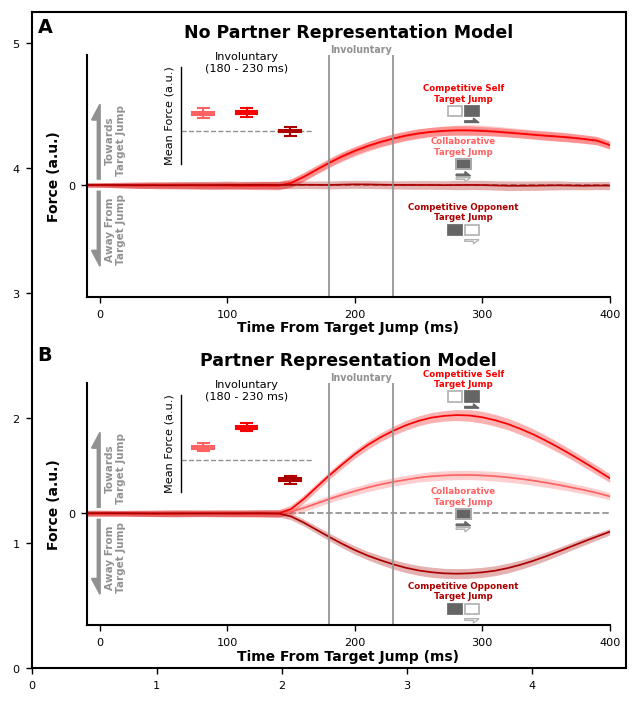

In [11]:
mosaic = [
        ["a", "a"],
        ["b", "b"],
    ]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(4.75, 5.25),
)
axes = list(fig.axes.values())
inset_xlocs = np.arange(0, 7, 1)
for i, model_name in enumerate(["exp1_ofc", "exp1_gto"]):
    ax = axes[i]
    inset_ax = ax.inset_axes((0.18, 0.55, 0.25, 0.4))
    legend_inset_yvals = [[0.5, 0.72, 0.23], [0.41, 0.895, 0.02]]
    legend_inset_xvals = [0.66, 0.66, 0.66]
    for j, condition in enumerate(const.condition_names_collapsed[:3]):
        df = probe_model_df.filter(
            pl.col("model_name") == model_name,
            pl.col("condition") == const.condition_names[j],
            pl.col("time_from_jump").is_between(-50, 400),
        )
        traces = df.group_by(pl.col("trial"), maintain_order=True).agg(
            pl.col("time_from_jump", "p1_applied_force")
        )
        timepoints = traces["time_from_jump"][0]
        force = np.vstack(traces["p1_applied_force"]).T
        mean_force = np.mean(force, axis=1)
        std_force = np.std(force, axis=1)

        ax.plot(timepoints, mean_force, color=const.condition_colors_light[j], lw=1)

        over = mean_force + std_force
        under = mean_force - std_force
        ax.fill_between(
            timepoints,
            over,
            under,
            color=const.condition_colors_light[j],
            alpha=0.3,
            lw=0,
        )

        # Plot on inset
        involuntary_force = (
            df.filter(pl.col("time_from_jump").is_between(180, 230))
            .group_by(pl.col("trial"), maintain_order=True)
            .mean()["p1_applied_force"]
            .to_numpy()
        )
        dv.boxplot(
            inset_ax,
            x=inset_xlocs[j],
            data=involuntary_force,
            jitter_data=False,
            color=const.condition_colors_light[j],
        )

        # Plot legend insets
        pf.target_legend(
            ax=ax,
            inset_x=legend_inset_xvals[i],
            inset_y=legend_inset_yvals[i][j],
            inset_w=0.12,
            inset_h=0.12,
            xpos=0.5,
            ypos=0.4,
            target_height=0.35,
            target_width=0.23,
            jump_distance=0.27,
            label_color=const.condition_colors_light[j],
            label_name=const.condition_labels[j],
            condition_name=const.condition_names_collapsed[j],
            arrow_lw=0.75,
            arrow_head_length=0.09,
            arrow_head_width=0.3,
            arrow_yshift=0.06,
            tail_width=0.12,
            inset_axis_off=True,
            fontsize=5,
            transform=transforms.blended_transform_factory(
                ax.transAxes, ax.transAxes
            ),
        )
    # x-axis at 0
    ax.axhline(0, lw=1, ls="--", alpha=1, color=wheel.grey, zorder=-10)

    # Involuntary Region
    ax.axvline(180, color=wheel.grey, lw=1)
    ax.axvline(230, color=wheel.grey, lw=1)
    ax.text(
        205,
        1.04,
        "Involuntary",
        transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
        rotation=0,
        color=wheel.grey,
        fontsize=5.5,
        va="top",
        ha="center",
        fontweight="bold",
    )

    # Towards/Away Arrows
    pf.plot_towards_away_arrows(
        ax,
        0,
        [0.1, -0.1],
        dy=1.2,
        head_width=13,
        head_length=0.25,
        tail_width=4,
        text_yshifts=[0.62, -0.61],
        text_xshift=12,
    )

    ax.set_ylim(-1.8, 2.1)
    ax.set_xticks(np.arange(0, 401, 100))
    ax.set_yticks([0])
    ax.set_yticklabels(["0"])
    ax.set_xlim(-10, 400)
    ax.set_ylabel("Force (a.u.)")
    ax.set_xlabel("Time From Target Jump (ms)", labelpad=1)

    inset_ax.set_ylim(-1, 2)
    inset_ax.tick_params(axis="x", which="major", pad=1)
    inset_ax.set_xticklabels([])
    inset_ax.set_xticks([])
    inset_ax.set_yticklabels([])
    inset_ax.set_yticks([])
    inset_ax.spines["bottom"].set_visible(False)
    inset_ax.spines["left"].set_linewidth(0.8)
    inset_ax.set_ylabel("Mean Force (a.u.)", fontsize=6.5, fontweight="regular")
    inset_ax.set_title(
        "Involuntary\n(180 - 230 ms)", fontsize=6.5, y=0.85, fontweight="regular"
    )
    inset_ax.axhline(0, ls="--", color=wheel.grey, lw=0.8, zorder=0)

fig.add_all_letters(horizontalshift=-0.35, verticalshift=0.28, fontsize=11)
fig.axes["a"].set_title("No Partner Representation Model", pad=10, fontsize=10)
fig.axes["b"].set_title("Partner Representation Model", pad=10, fontsize=10)

plt.show()

# Position Traces Interactive Conditions

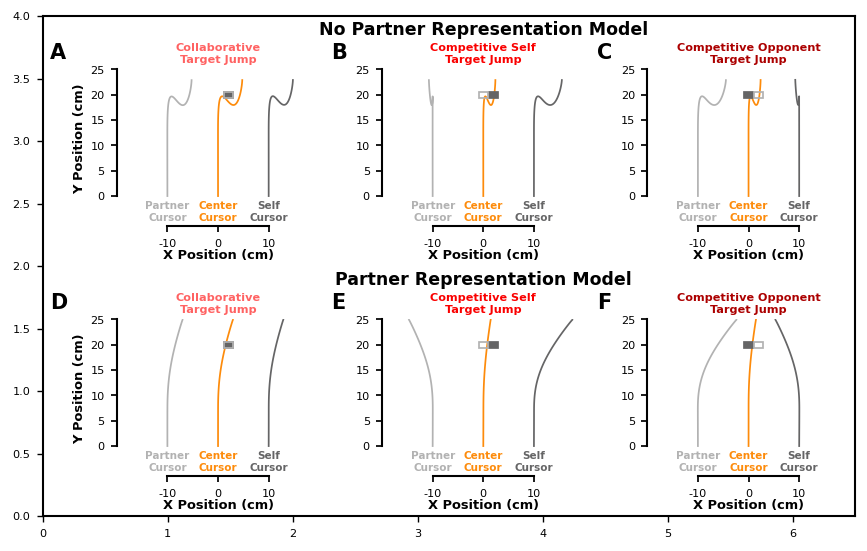

In [14]:
model_names = [
    "exp1_ofc",
    "exp1_gto",
]
mosaic = [
    ["a", "b", "c"],
    ["d", "e", "f"],
]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(6.5, 4),
)

jump_dist = [0.02, 0.02, 0]
partner_jump_dist = [0.02, 0, 0.02]
for e, model in enumerate(model_names):
    for c, condition in enumerate(const.condition_names[:3]):
        ax = fig.axes[mosaic[e][c]]
        df = (
            regular_model_df.filter(
                pl.col("model_name") == model,
                pl.col("condition") == condition,
            )
            .group_by(pl.col("timepoint"), maintain_order=True)
            .mean()
        )

        ax.plot(df["rhx"], df["rhy"], color=const.self_color, lw=1)
        ax.plot(df["lhx"], df["lhy"], color=const.partner_color, lw=1)
        ax.plot(df["ccx"], df["ccy"], color=const.cc_color, lw=1)

        ax.set_xlim(-0.2, 0.2)
        ax.set_ylim(-0.06, 0.25)
        ax.set_aspect("equal")
        ax.spines.bottom.set_bounds(-0.1, 0.1)
        ax.spines.left.set_bounds(0, 0.25)
        ax.set_xticks([-0.1, 0.0, 0.1], labels=["-10", "0", "10"])
        ax.set_yticks(np.arange(0, 0.26, 0.05), labels=["0", "5", "10", "15", "20", "25"])
        ax.tick_params(width=1)  # Change width to desired thickness

        # Self, Partner labels
        ax.text(
            0.1, -0.01, "Self\nCursor", fontsize=6, color=const.self_color, ha="center", va="top", fontweight="bold"
        )
        ax.text(
            -0.1,
            -0.01,
            "Partner\nCursor",
            fontsize=6,
            color=const.partner_color,
            ha="center",
            va="top",
            fontweight="bold",
        )
        ax.text(
            0, -0.01, "Center\nCursor", fontsize=6, color=const.cc_color, ha="center", va="top", fontweight="bold"
        )

        # Plot targets on reaching
        partial_plot_jump_targets = functools.partial(
            pf.plot_jump_targets,
            x=0.0,
            y=0.20 - 0.0125,  # need this -0.0125 for some reason
            width=0.0175,
            height=0.0125,
            target_arrow_length=0.08,
            target_arrow_label="1",
        )
        partial_plot_jump_targets(
            ax=ax,
            probe=False,
            plot_arrows=False,
            jump_dist=jump_dist[c],
            partner_jump_dist=partner_jump_dist[c],
            transform=ax.transData,
        )
        ax.set_xlabel("X Position (cm)", labelpad=0.2, fontsize=7.5)
        ax.text(
            0,
            0.26,
            const.condition_labels[c],
            fontsize=6.5,
            ha="center",
            va="bottom",
            fontweight="bold",
            color=const.condition_colors_light[c],
        )

fig.axes["a"].set_ylabel("Y Position (cm)", fontsize=7.5)
fig.axes["a"].yaxis.set_label_coords(-0.15, 0.56)
fig.axes["d"].set_ylabel("Y Position (cm)", fontsize=7.5)
fig.axes["d"].yaxis.set_label_coords(-0.15, 0.56)
fig.add_letter(fig.axes["a"], -0.33, 1.17, "A")
fig.add_letter(fig.axes["b"], -0.25, 1.17, "B")
fig.add_letter(fig.axes["c"], -0.25, 1.17, "C")
fig.add_letter(fig.axes["d"], -0.33, 1.17, "D")
fig.add_letter(fig.axes["e"], -0.25, 1.17, "E")
fig.add_letter(fig.axes["f"], -0.25, 1.17, "F")
fig.axes["b"].set_title("No Partner Representation Model", fontsize=10, pad=20)
fig.axes["e"].set_title("Partner Representation Model", fontsize=10, pad=20)
plt.show()

# Position Traces Solo Conditions

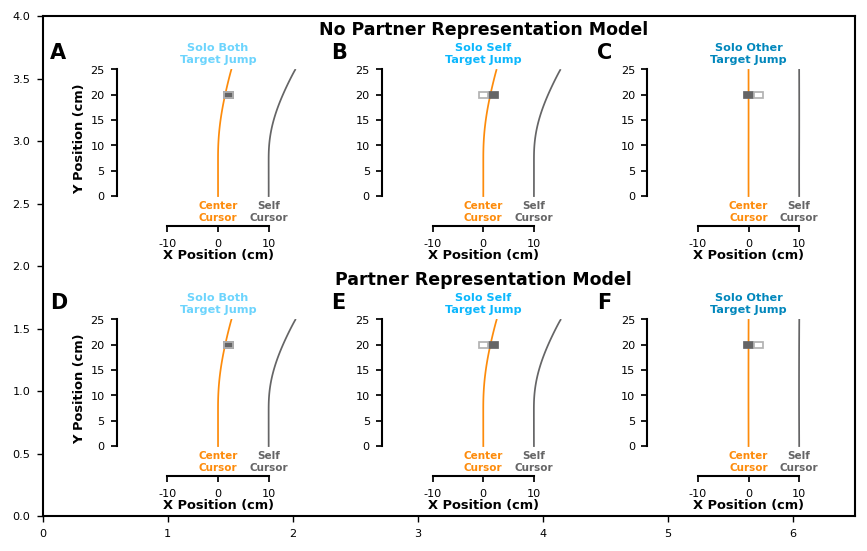

In [15]:
model_names = [
    "exp1_ofc",
    "exp1_gto",
]
mosaic = [
    ["a", "b", "c"],
    ["d", "e", "f"],
]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(6.5, 4),
)

jump_dist = [0.02, 0.02, 0]
partner_jump_dist = [0.02, 0, 0.02]
for e, model in enumerate(model_names):
    for c in range(3, 6):
        condition = const.condition_names[c]
        ax = fig.axes[mosaic[e][c - 3]]
        df = (
            regular_model_df.filter(
                pl.col("model_name") == model,
                pl.col("condition") == condition,
            )
            .group_by(pl.col("timepoint"), maintain_order=True)
            .mean()
        )

        ax.plot(df["rhx"], df["rhy"], color=const.self_color, lw=1)
        ax.plot(df["ccx"], df["ccy"], color=const.cc_color, lw=1)

        ax.set_xlim(-0.2, 0.2)
        ax.set_ylim(-0.06, 0.25)
        ax.set_aspect("equal")
        ax.spines.bottom.set_bounds(-0.1, 0.1)
        ax.spines.left.set_bounds(0, 0.25)
        ax.set_xticks([-0.1, 0.0, 0.1], labels=["-10", "0", "10"])
        ax.set_yticks(np.arange(0, 0.26, 0.05), labels=["0", "5", "10", "15", "20", "25"])
        ax.tick_params(width=1)  # Change width to desired thickness

        # Self, Partner labels
        ax.text(
            0.1, -0.01, "Self\nCursor", fontsize=6, color=const.self_color, ha="center", va="top", fontweight="bold"
        )
        ax.text(
            0, -0.01, "Center\nCursor", fontsize=6, color=const.cc_color, ha="center", va="top", fontweight="bold"
        )

        # Plot targets on reaching
        partial_plot_jump_targets = functools.partial(
            pf.plot_jump_targets,
            x=0.0,
            y=0.20 - 0.0125,  # need this -0.0125 for some reason
            width=0.0175,
            height=0.0125,
            target_arrow_length=0.08,
            target_arrow_label="1",
        )
        partial_plot_jump_targets(
            ax=ax,
            probe=False,
            plot_arrows=False,
            jump_dist=jump_dist[c - 3],
            partner_jump_dist=partner_jump_dist[c - 3],
            transform=ax.transData,
        )
        ax.set_xlabel("X Position (cm)", labelpad=0.2, fontsize=7.5)
        ax.text(
            0,
            0.26,
            const.condition_labels[c],
            fontsize=6.5,
            ha="center",
            va="bottom",
            fontweight="bold",
            color=const.condition_colors_light[c],
        )

fig.axes["a"].set_ylabel("Y Position (cm)", fontsize=7.5)
fig.axes["a"].yaxis.set_label_coords(-0.15, 0.56)
fig.axes["d"].set_ylabel("Y Position (cm)", fontsize=7.5)
fig.axes["d"].yaxis.set_label_coords(-0.15, 0.56)
fig.add_letter(fig.axes["a"], -0.33, 1.17, "A")
fig.add_letter(fig.axes["b"], -0.25, 1.17, "B")
fig.add_letter(fig.axes["c"], -0.25, 1.17, "C")
fig.add_letter(fig.axes["d"], -0.33, 1.17, "D")
fig.add_letter(fig.axes["e"], -0.25, 1.17, "E")
fig.add_letter(fig.axes["f"], -0.25, 1.17, "F")
fig.axes["b"].set_title("No Partner Representation Model", fontsize=10, pad=20)
fig.axes["e"].set_title("Partner Representation Model", fontsize=10, pad=20)
plt.show()

Solo vs Interactive Main Models Feedback Responses

0
solo_same_jump
1
joint_same_jump
2
solo_p1_jump
3
joint_p1_jump
4
solo_p2_jump
5
joint_p2_jump
0
solo_same_jump
1
joint_same_jump
2
solo_p1_jump
3
joint_p1_jump
4
solo_p2_jump
5
joint_p2_jump


Text(0.5, 1.0, 'Partner Representation Model')

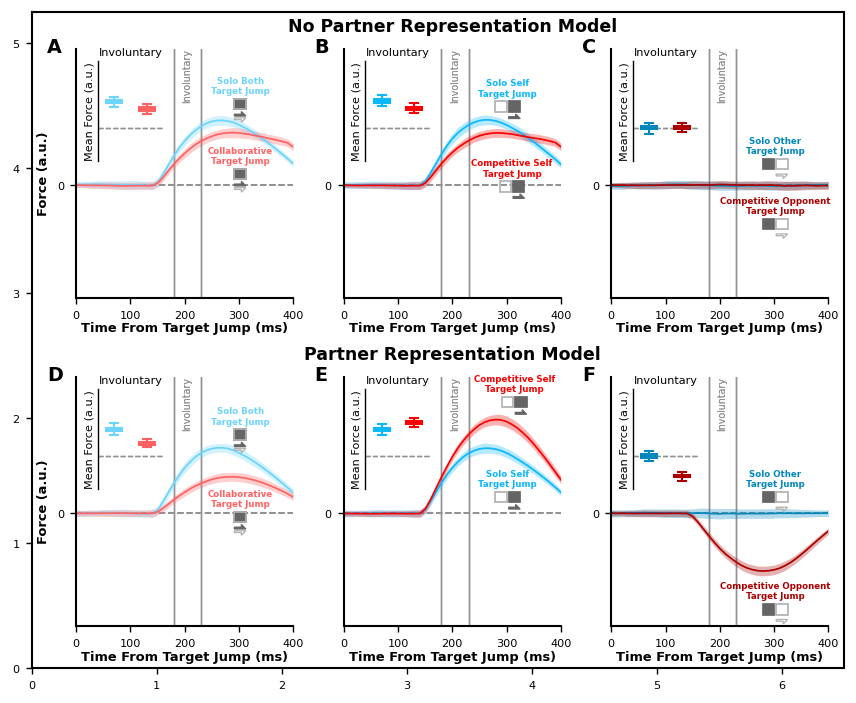

In [18]:
mosaic = [
    ["a", "b", "c"],
    ["d", "e", "f"],
]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(6.5, 5.25),
)
axes = list(fig.axes.values())
inset_xlocs = [0, 1]
inset_axes = [ax.inset_axes([0.1, 0.55, 0.3, 0.4]) for ax in axes]
ax_plot_index = [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]
ax_plot_counter = -1
for i, model_name in enumerate(["exp1_ofc", "exp1_gto"]):
    c = -1
    for j in range(3):
        ax = fig.axes[mosaic[i][j]]
        for k in range(2):
            c += 1
            ax_plot_counter += 1
            ax_idx = ax_plot_index[ax_plot_counter]
            condition = const.condition_names_alt[c]
            print(c)
            print(condition)

            legend_inset_yvals = [
                [(0.73, 0.45), (0.72, 0.40), (0.49, 0.25)],
                [(0.72, 0.39), (0.47, 0.85), (0.47, 0.02)],
                [(0.72, 0.39), (0.47, 0.85), (0.47, 0.02)],
            ]
            legend_inset_xvals = [
                [(0.64, 0.64), (0.64, 0.66), (0.64, 0.64)],
                [(0.64, 0.64), (0.64, 0.67), (0.64, 0.64)],
                [(0.64, 0.64), (0.64, 0.67), (0.64, 0.64)],
            ]
            df = probe_model_df.filter(
                pl.col("model_name") == model_name,
                pl.col("condition") == condition,
                pl.col("time_from_jump").is_between(-50, 400),
            )
            traces = df.group_by(pl.col("trial"), maintain_order=True).agg(
                pl.col("time_from_jump", "p1_applied_force")
            )
            timepoints = traces["time_from_jump"][0]
            force = np.vstack(traces["p1_applied_force"]).T
            mean_force = np.mean(force, axis=1)
            std_force = np.std(force, axis=1)

            ax.plot(timepoints, mean_force, color=const.condition_colors_light_alt[c], lw=1)

            over = mean_force + std_force
            under = mean_force - std_force
            ax.fill_between(timepoints, over, under, color=const.condition_colors_light_alt[c], alpha=0.3, lw=0)

            # Plot on inset
            involuntary_force = (
                df.filter(pl.col("time_from_jump").is_between(180, 230))
                .group_by(pl.col("trial"), maintain_order=True)
                .mean()["p1_applied_force"]
                .to_numpy()
            )
            dv.boxplot(
                inset_axes[ax_idx],
                x=inset_xlocs[k],
                data=involuntary_force,
                jitter_data=False,
                color=const.condition_colors_light_alt[c],
            )

            # Plot legend insets
            pf.target_legend(
                ax=ax,
                inset_x=legend_inset_xvals[i][j][k],
                inset_y=legend_inset_yvals[i][j][k],
                inset_w=0.23,
                inset_h=0.12,
                xpos=0.5,
                ypos=0.4,
                target_height=0.35,
                target_width=0.23,
                jump_distance=0.27,
                label_color=const.condition_colors_light_alt[c],
                label_name=const.condition_labels_alt[c],
                condition_name=const.condition_names_collapsed_alt[c],
                arrow_lw=0.75,
                arrow_head_length=0.09,
                arrow_head_width=0.3,
                arrow_yshift=0.06,
                tail_width=0.12,
                inset_axis_off=True,
                fontsize=5,
                transform=transforms.blended_transform_factory(ax.transAxes, ax.transAxes),
            )
            # x-axis at 0
            ax.axhline(0, lw=1, ls="--", alpha=1, color=wheel.grey, zorder=-10)

            # Involuntary Region
            ax.axvline(180, color=wheel.grey, lw=0.8, zorder=-100)
            ax.axvline(230, color=wheel.grey, lw=0.8, zorder=-100)
            ax.text(
                205,
                1,
                "Involuntary",
                transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
                rotation=90,
                color=wheel.grey,
                fontsize=5.5,
                va="top",
                ha="center",
                fontweight="regular",
            )

            # Towards/Away Arrows
            # pf.plot_towards_away_arrows(ax, 0, [0.1,-0.1],
            #                         dy=1.2, head_width=13, head_length=0.25,
            #                         tail_width=4, text_yshifts=[0.62, -0.61], text_xshift=12)

            ax.set_ylim(-1.9, 2.3)
            ax.set_xticks(np.arange(0, 401, 100))
            ax.set_yticks([0])
            ax.set_yticklabels([0])
            ax.set_xlim(-0, 400)
            if j == 0:
                ax.set_ylabel("Force (a.u.)", fontsize=7.5)
            ax.set_xlabel("Time From Target Jump (ms)", labelpad=1, fontsize=7.5)

            inset_axes[c].set_ylim(-1, 2)
            inset_axes[c].tick_params(axis="x", which="major", pad=1)
            inset_axes[c].set_xticklabels([])
            inset_axes[c].set_xticks([])
            inset_axes[c].set_yticklabels([])
            inset_axes[c].set_yticks([])
            inset_axes[c].spines["bottom"].set_visible(False)
            inset_axes[c].spines["left"].set_linewidth(0.8)
            inset_axes[c].set_ylabel("Mean Force (a.u.)", fontsize=6.5, fontweight="regular", labelpad=2)
            inset_axes[c].set_title("Involuntary", fontsize=6.5, y=0.95, fontweight="regular")
            inset_axes[c].axhline(0, ls="--", color=wheel.grey, lw=0.8, zorder=0)

fig.add_all_letters(horizontalshift=-0.2, verticalshift=0.08, fontsize=11)
fig.axes["b"].set_title("No Partner Representation Model", pad=10, fontsize=10)
fig.axes["e"].set_title("Partner Representation Model", pad=10, fontsize=10)

# Solo vs Interactive Alternate Model Feedback Responses

Text(0.55, 1.1, 'Partner Representation\nEqual Joint Cost')

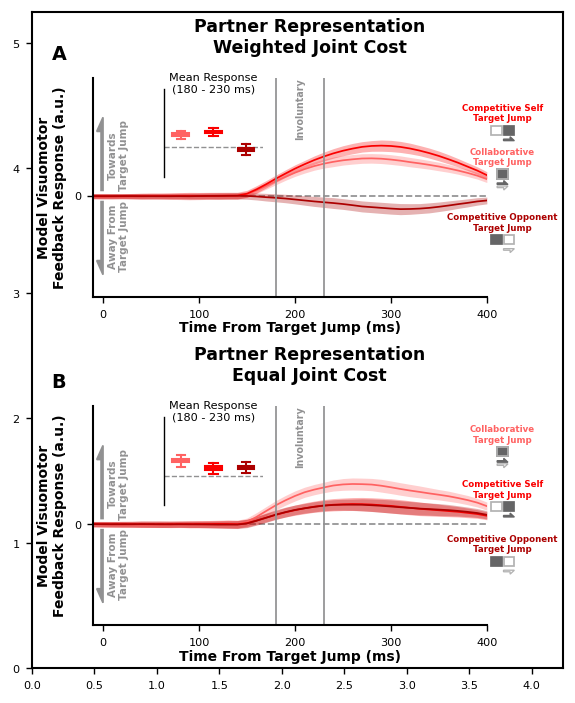

In [19]:
mosaic = [
    ["a", "a"],
    ["b", "b"],
]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(4.25, 5.25),
)
axes = list(fig.axes.values())
inset_xlocs = np.arange(0, 7, 1)
for i, model_name in enumerate(["exp1_gto_wtd_joint_cost", "exp1_gto_joint_cost"]):
    ax = axes[i]
    inset_ax = ax.inset_axes((0.18, 0.55, 0.25, 0.4))
    legend_inset_yvals = [
        [0.52, 0.72, 0.22],
        [0.75, 0.5, 0.25], 
    ]
    legend_inset_xvals = [0.98, 0.98, 0.98]
    for j, condition in enumerate(const.condition_names[:3]):
        df = probe_model_df.filter(
            pl.col("model_name") == model_name,
            pl.col("condition") == condition,
            pl.col("time_from_jump").is_between(-50, 400),
        )
        traces = df.group_by(pl.col("trial"), maintain_order=True).agg(
            pl.col("time_from_jump", "p1_applied_force")
        )
        timepoints = traces["time_from_jump"][0]
        force = np.vstack(traces["p1_applied_force"]).T
        mean_force = np.mean(force, axis=1)
        std_force = np.std(force, axis=1)

        ax.plot(timepoints, mean_force, color=const.condition_colors_light[j], lw=1)

        over = mean_force + std_force
        under = mean_force - std_force
        ax.fill_between(
            timepoints,
            over,
            under,
            color=const.condition_colors_light[j],
            alpha=0.3,
            lw=0,
        )

        # Plot on inset
        involuntary_force = (
            df.filter(pl.col("time_from_jump").is_between(180, 230))
            .group_by(pl.col("trial"), maintain_order=True)
            .mean()["p1_applied_force"]
            .to_numpy()
        )
        dv.boxplot(
            inset_ax,
            x=inset_xlocs[j],
            data=involuntary_force,
            jitter_data=False,
            color=const.condition_colors_light[j],
        )

        # Plot legend insets
        pf.target_legend(
            ax=ax,
            inset_x=legend_inset_xvals[i],
            inset_y=legend_inset_yvals[i][j],
            inset_w=0.12,
            inset_h=0.12,
            xpos=0.5,
            ypos=0.35,
            target_height=0.35,
            target_width=0.23,
            jump_distance=0.27,
            label_color=const.condition_colors_light[j],
            label_name=const.condition_labels[j],
            condition_name=const.condition_names_collapsed[j],
            arrow_lw=0.75,
            arrow_head_length=0.09,
            arrow_head_width=0.3,
            arrow_yshift=0.06,
            tail_width=0.12,
            inset_axis_off=True,
            fontsize=5,
            transform=transforms.blended_transform_factory(
                ax.transAxes, ax.transAxes
            ),
        )
    # x-axis at 0
    ax.axhline(0, lw=1, ls="--", alpha=1, color=wheel.grey, zorder=-10)

    # Involuntary Region
    ax.axvline(180, color=wheel.grey, lw=1)
    ax.axvline(230, color=wheel.grey, lw=1)
    ax.text(
        205,
        1.0,
        "Involuntary",
        transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
        rotation=90,
        color=wheel.grey,
        fontsize=5.5,
        va="top",
        ha="center",
        fontweight="bold",
    )

    # Towards/Away Arrows
    pf.plot_towards_away_arrows(
        ax,
        0,
        [0.1, -0.1],
        dy=1.3,
        head_width=13,
        head_length=0.25,
        tail_width=4,
        text_yshifts=[0.62, -0.61],
        text_xshift=16,
    )

    ax.set_ylim(-1.8, 2.1)
    ax.set_xticks(np.arange(0, 401, 100))
    ax.set_yticks([0])
    ax.set_yticklabels(["0"])
    ax.set_xlim(-10, 400)
    ax.set_ylabel("Model Visuomotor\nFeedback Response (a.u.)")
    ax.set_xlabel("Time From Target Jump (ms)", labelpad=1)

    inset_ax.set_ylim(-1, 2)
    inset_ax.tick_params(axis="x", which="major", pad=1)
    inset_ax.set_xticklabels([])
    inset_ax.set_xticks([])
    inset_ax.set_yticklabels([])
    inset_ax.set_yticks([])
    inset_ax.spines["bottom"].set_visible(False)
    inset_ax.spines["left"].set_linewidth(0.8)
    inset_ax.set_title(
        "Mean Response\n(180 - 230 ms)", fontsize=6.5, y=0.85, fontweight="regular"
    )
    inset_ax.axhline(0, ls="--", color=wheel.grey, lw=0.8, zorder=0)

fig.add_all_letters(horizontalshift=-0.35, verticalshift=0.28, fontsize=11)
fig.axes["a"].text(0.55, 1.1, "Partner Representation\nWeighted Joint Cost", va='bottom',ha='center', 
                    fontsize=10, fontweight='bold',
                    transform=fig.axes['a'].transAxes)
fig.axes["b"].text(0.55, 1.1, "Partner Representation\nEqual Joint Cost", va='bottom',ha='center', 
                    fontsize=10, fontweight='bold',
                    transform=fig.axes['b'].transAxes)

# Solo vs Interactive Alternate Model Feedback Responses

Text(0.5, 1.0, 'Partner Representation\nEqual Joint Cost')

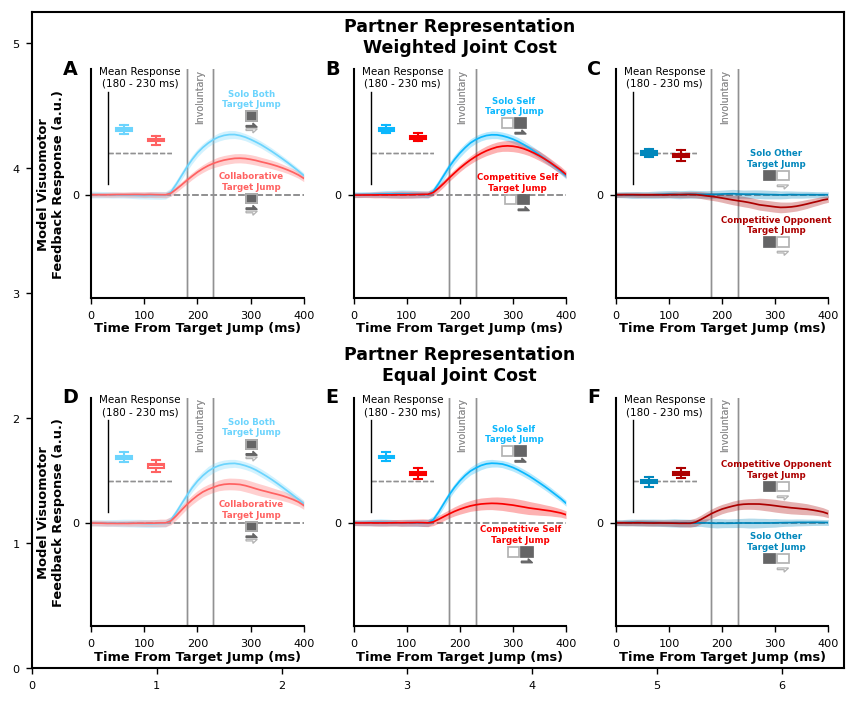

In [21]:
mosaic = [
    ["a", "b", "c"],
    ["d", "e", "f"],
]
fig = dv.AutoFigure(
    mosaic=mosaic,
    dpi=125,
    figsize=(6.5, 5.25),
)
axes = list(fig.axes.values())
inset_xlocs = [0, 1]
inset_axes = [ax.inset_axes([0.08, 0.5, 0.3, 0.4]) for ax in axes]
ax_plot_index = [0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6]
ax_plot_counter = -1
for i, model_name in enumerate(["exp1_gto_wtd_joint_cost", "exp1_gto_joint_cost"]):
    c = -1
    for j in range(3):
        ax = fig.axes[mosaic[i][j]]
        for k in range(2):
            c += 1
            ax_plot_counter += 1
            ax_idx = ax_plot_index[ax_plot_counter]
            condition = const.condition_names_alt[c]

            legend_inset_yvals = [
                [(0.75, 0.39), (0.72, 0.385), (0.49, 0.2)],
                [(0.75, 0.39), (0.72, 0.28), (0.25, 0.565)],
            ]
            legend_inset_xvals = [
                [(0.64, 0.64), (0.64, 0.655), (0.64, 0.64)],
                [(0.64, 0.64), (0.64, 0.67), (0.64, 0.64)],
            ]
            df = probe_model_df.filter(
                pl.col("model_name") == model_name,
                pl.col("condition") == condition,
                pl.col("time_from_jump").is_between(-50, 400),
            )
            traces = df.group_by(pl.col("trial"), maintain_order=True).agg(
                pl.col("time_from_jump", "p1_applied_force")
            )
            timepoints = traces["time_from_jump"][0]
            force = np.vstack(traces["p1_applied_force"]).T
            mean_force = np.mean(force, axis=1)
            std_force = np.std(force, axis=1)

            ax.plot(timepoints, mean_force, color=const.condition_colors_light_alt[c], lw=1)

            over = mean_force + std_force
            under = mean_force - std_force
            ax.fill_between(timepoints, over, under, color=const.condition_colors_light_alt[c], alpha=0.3, lw=0)

            # Plot on inset
            involuntary_force = (
                df.filter(pl.col("time_from_jump").is_between(180, 230))
                .group_by(pl.col("trial"), maintain_order=True)
                .mean()["p1_applied_force"]
                .to_numpy()
            )
            dv.boxplot(
                inset_axes[ax_idx],
                x=inset_xlocs[k],
                data=involuntary_force,
                jitter_data=False,
                color=const.condition_colors_light_alt[c],
            )

            # Plot legend insets
            pf.target_legend(
                ax=ax,
                inset_x=legend_inset_xvals[i][j][k],
                inset_y=legend_inset_yvals[i][j][k],
                inset_w=0.23,
                inset_h=0.12,
                xpos=0.5,
                ypos=0.38,
                target_height=0.35,
                target_width=0.23,
                jump_distance=0.27,
                label_color=const.condition_colors_light_alt[c],
                label_name=const.condition_labels_alt[c],
                condition_name=const.condition_names_collapsed_alt[c],
                arrow_lw=0.75,
                arrow_head_length=0.09,
                arrow_head_width=0.3,
                arrow_yshift=0.06,
                tail_width=0.12,
                inset_axis_off=True,
                fontsize=5,
                transform=transforms.blended_transform_factory(ax.transAxes, ax.transAxes),
            )
            # x-axis at 0
            ax.axhline(0, lw=1, ls="--", alpha=1, color=wheel.grey, zorder=-10)

            # Involuntary Region
            ax.axvline(180, color=wheel.grey, lw=0.8, zorder=-100)
            ax.axvline(230, color=wheel.grey, lw=0.8, zorder=-100)
            ax.text(
                205,
                1,
                "Involuntary",
                transform=transforms.blended_transform_factory(ax.transData, ax.transAxes),
                rotation=90,
                color=wheel.grey,
                fontsize=5.5,
                va="top",
                ha="center",
                fontweight="regular",
            )

            # Towards/Away Arrows
            # pf.plot_towards_away_arrows(ax, 0, [0.1,-0.1],
            #                         dy=1.2, head_width=13, head_length=0.25,
            #                         tail_width=4, text_yshifts=[0.62, -0.61], text_xshift=12)

            ax.set_ylim(-1.9, 2.3)
            ax.set_xticks(np.arange(0, 401, 100))
            ax.set_yticks([0])
            ax.set_yticklabels([0])
            ax.set_xlim(-0, 400)
            if j == 0:
                ax.set_ylabel("Model Visuomotor\nFeedback Response (a.u.)", fontsize=7.5)
            ax.set_xlabel("Time From Target Jump (ms)", labelpad=1, fontsize=7.5)

            inset_axes[c].set_ylim(-1, 2)
            inset_axes[c].tick_params(axis="x", which="major", pad=1)
            inset_axes[c].set_xticklabels([])
            inset_axes[c].set_xticks([])
            inset_axes[c].set_yticklabels([])
            inset_axes[c].set_yticks([])
            inset_axes[c].spines["bottom"].set_visible(False)
            inset_axes[c].spines["left"].set_linewidth(0.8)
            inset_axes[c].set_title("Mean Response\n(180 - 230 ms)", fontsize=6, y=0.95, fontweight="regular")
            inset_axes[c].axhline(0, ls="--", color=wheel.grey, lw=0.8, zorder=0)

fig.add_all_letters(horizontalshift=-0.2, verticalshift=0.08, fontsize=11)
fig.axes["b"].set_title("Partner Representation\nWeighted Joint Cost", pad=10, fontsize=10)
fig.axes["e"].set_title("Partner Representation\nEqual Joint Cost", pad=10, fontsize=10)



# Feedback gains

In [12]:
# Load in ofc and selfish gto model objects 
# Fdbck gains are same across all joint conditions so just load joint_p1_jump
with open( MODEL_PATH / "model_object_exp1_gto_joint_p1_jump.pkl", "rb") as f:
    gto_model = dill.load(f)
with open(MODEL_PATH / "model_object_exp1_ofc_joint_p1_jump.pkl", "rb") as f:
    ofc_model = dill.load(f)
with open( MODEL_PATH / "model_object_exp1_gto_joint_cost_joint_p1_jump.pkl", "rb") as f:
    gto_joint_cost_model = dill.load(f)
with open( MODEL_PATH / "model_object_exp1_gto_wtd_joint_cost_joint_p1_jump.pkl", "rb") as f:
    gto_wtd_joint_cost_model = dill.load(f)

exp1_ofc with partner_knowledge=False
exp1_gto with partner_knowledge=True
exp1_gto_wtd_joint_cost with partner_knowledge=True
exp1_gto_joint_cost with partner_knowledge=True


Text(0.5, 1.0, 'Partner Representation\nEqual Joint Cost')

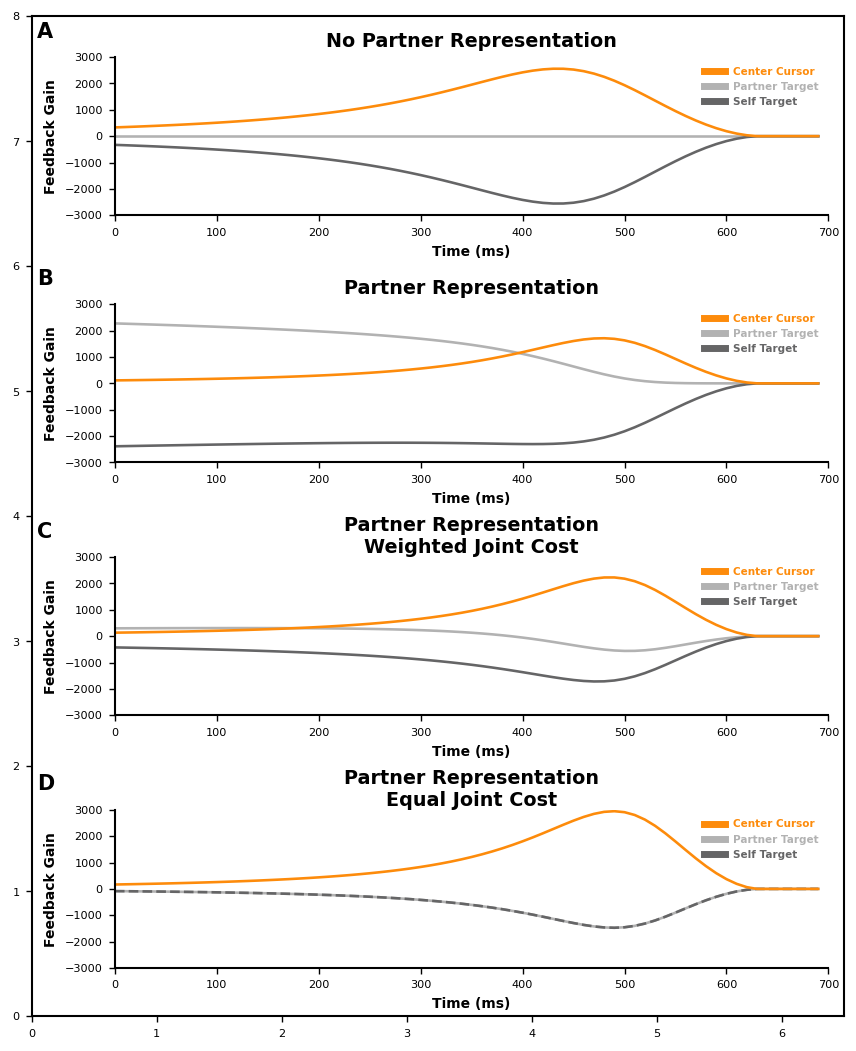

In [13]:
fig = dv.AutoFigure('a;b;c;d', dpi=125, figsize=(6.5, 8))
axes = list(fig.axes.values())
sm = gto_model.dynamics.state_mapping
models = [ofc_model, gto_model, gto_wtd_joint_cost_model, gto_joint_cost_model]
cc_adjs = [-25, -50, -25, 50]

for i, model in enumerate(models):
    print(model)
    F1_self_x = model.p1_policy.F[:,0,sm['rtx']]
    F1_partner_x = model.p1_policy.F[:,0,sm['ltx']]
    F1_cc_x = model.p1_policy.F[:,0,sm['ccx']]
    # F1_added_targets = F1_partner_x + F1_self_x

    self_ls = '--' if i == 3 else '-'
    axes[i].plot(F1_partner_x[:70], label='Partner', color=const.partner_color)
    axes[i].plot(F1_self_x[:70], label='Self', color=const.self_color, linestyle=self_ls)
    axes[i].plot(F1_cc_x[:70], color=const.cc_color)
    # axes[i].plot(F1_added_targets[:70], label='Added Targets', color=const.blue)
    
    # ylim and vline for target hit
    axes[i].set_ylim(-3000, 3000)
    # axes[i].axvline(params.VIA_T*100, color=wheel.lavender, zorder=-100)
    # axes[i].text(params.VIA_T*100 - 1.1, axes[i].get_ylim()[1], "Target\nHit Time", rotation=90, 
    #              color=wheel.lavender, fontweight='bold', fontsize=6, ha='center', va='top')

    # Add text to label the lines
    text_xloc = np.argmax(F1_cc_x)
    st_adj = 0 if i == 0 else 50
    # axes[i].text(text_xloc, F1_self_x[text_xloc] - 350 + st_adj, "Self Target", color=const.self_color, fontsize=6, fontweight='bold', ha='center')
    # axes[i].text(text_xloc, F1_partner_x[text_xloc] + 100, "Partner Target", color=const.partner_color, fontsize=6, fontweight='bold', ha='center')
    # axes[i].text(text_xloc, F1_cc_x[text_xloc] + 250 + cc_adjs[i], "Center Cursor", color=const.cc_color, fontsize=6, fontweight='bold', ha='center')
    # Arrows starting at 1000 and -1000 to label towards/away from target
    # axes[i].arrow(0.5, 1000, 0, 1750, head_width=1.25, head_length=500, color='black',
    #               shape='left',
    #               length_includes_head=True)
    
    
    axes[i].set_xticks(np.linspace(0, 70, 8), labels=np.linspace(0, 70, 8, dtype=int)*10)

    axes[i].set_ylabel("Feedback Gain")
    axes[i].set_xlabel("Time (ms)")
    dv.custom_legend(axes[i], ["Center Cursor", "Partner Target", "Self Target"], 
                        colors=[const.cc_color, const.partner_color, const.self_color], 
                        fontsize=6, loc='upper right')
fig.add_all_letters(horizontalshift=-0.55, verticalshift=0.3, fontsize=12)

axes[0].set_title("No Partner Representation", fontsize=11)
axes[1].set_title("Partner Representation", fontsize=11)
axes[2].set_title("Partner Representation\nWeighted Joint Cost", fontsize=11, pad=0)
axes[3].set_title("Partner Representation\nEqual Joint Cost", fontsize=11, pad=0)